# Sistem Rekomendasi Resep Makanan

## Pengantar Dataset

Dataset yang digunakan pada project ini adalah Food.com Recipes and Interactions yang bersumber dari platform Food.com dan tersedia melalui Kaggle. Dataset ini berisi lebih dari 230.000 data resep makanan dengan berbagai atribut seperti nama resep, durasi memasak, tags, kandungan nutrisi, jumlah langkah memasak, deskripsi, daftar bahan, dan jumlah bahan. Dataset dipilih karena memiliki jumlah data yang besar, struktur data yang lengkap, serta relevan untuk pengembangan sistem rekomendasi resep makanan berdasarkan karakteristik bahan, waktu memasak, dan informasi nutrisi. Dari sisi etika penggunaan, dataset ini merupakan data publik dan tidak memuat identitas pribadi pengguna, namun tetap memiliki potensi bias karena berasal dari satu platform resep tertentu sehingga preferensi makanan yang ditampilkan dapat lebih merepresentasikan pengguna Food.com.

## Pre Processing Data

#### Import dan load data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("RAW_recipes.csv")

#### Cek struktur dataset

In [4]:
print("Jumlah data:", df.shape)
print("\nData awal:")
df.head(2)

Jumlah data: (231637, 12)

Data awal:


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6


In [5]:
print(df.dtypes)

name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object


#### Data cleaning

In [6]:
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [7]:
df.dropna(
    subset=["name"],
    inplace=True
)

df["description"] = df[
    "description"
].fillna(
    "No description"
)

In [8]:
df.isnull().sum()

name              0
id                0
minutes           0
contributor_id    0
submitted         0
tags              0
nutrition         0
n_steps           0
steps             0
description       0
ingredients       0
n_ingredients     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

##### save dataset clean

In [10]:
df.to_csv("dataset_clean.csv", index=False)

In [11]:
# # merge dataset
# df = interactions.merge(
#     recipes,
#     left_on="recipe_id",
#     right_on="id",
#     how="inner"
# )

# df.to_csv(
#     "food_master_clean.csv",
#     index=False
# )
# df.head(2)

#### Parsing
Pada dataset, terdapat kolom yang menyimpan data dalam bentuk string. Jika diproses, python akan menganggapnya sebagai karakter biasa dan tidak dapat membaca angka angka gizi atau jumlah bahan di dalamnya.

In [12]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [13]:
df["nutrition"] = df[
    "nutrition"
].apply(
    ast.literal_eval
)

df["ingredients"] = df[
    "ingredients"
].apply(
    ast.literal_eval
)

df["tags"] = df[
    "tags"
].apply(
    ast.literal_eval
)

df["steps"] = df[
    "steps"
].apply(
    ast.literal_eval
)

In [14]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


---

#### EDA
Exploratory Data Analysis (EDA) dilakukan untuk mengenali karakterisitik sebaran data, mendeteksi outliers, serta melihat hubungan antar fitur sebelum data di training

##### analisis

In [15]:
print("Jumlah data:", df.shape)
df.describe()

Jumlah data: (231636, 12)


,id,minutes,contributor_id,n_steps,n_ingredients
count,231636.000000,2.316360e+05,2.316360e+05,231636.000000,231636.000000
mean,222014.077639,9.398587e+03,5.534906e+06,9.765516,9.051149
std,141206.613497,4.461973e+06,9.979162e+07,5.995136,3.734803
min,38.000000,0.000000e+00,2.700000e+01,0.000000,1.000000
25%,99943.750000,2.000000e+01,5.690500e+04,6.000000,6.000000
50%,207248.500000,4.000000e+01,1.736140e+05,9.000000,9.000000
75%,333815.250000,6.500000e+01,3.982750e+05,12.000000,11.000000
max,537716.000000,2.147484e+09,2.002290e+09,145.000000,43.000000


Terdapat 4 fitur numerik, yaitu `minutes`, `n_ingredient`, `n_step`, dan `rating`.

<Axes: xlabel='minutes', ylabel='Count'>

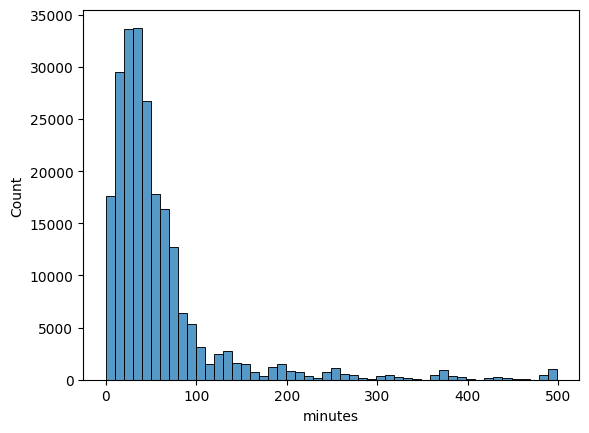

In [16]:
sns.histplot(
    df[df["minutes"] < 500]["minutes"],
    bins=50
)

<Axes: xlabel='n_ingredients', ylabel='Count'>

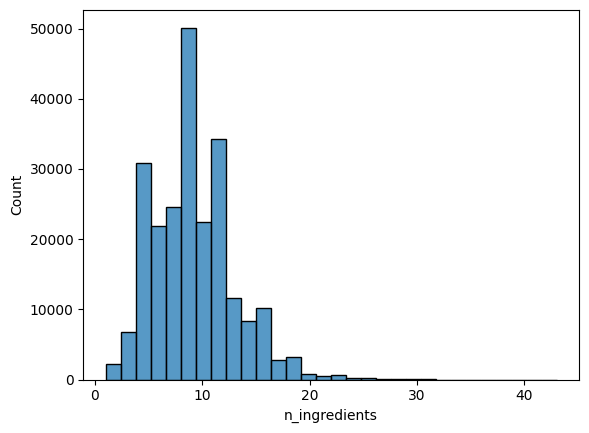

In [17]:
sns.histplot(
    df["n_ingredients"],
    bins=30
)

<Axes: xlabel='n_steps', ylabel='Count'>

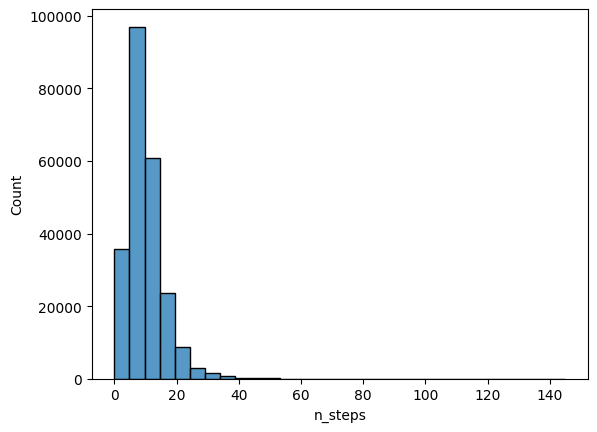

In [18]:
sns.histplot(df["n_steps"], bins=30)

---

##### validasi

Selanjutnya, dilakukan proses validasi data konkret menggunakan perintah pengurutan (.sort_values()) untuk memverifikasi nilai-resep paling ekstrem di batas bawah dan batas atas dataset—yaitu memeriksa apakah resep dengan durasi 0 menit murni merupakan hidangan mentah (seperti jus atau salad) dan resep dengan 43 bahan memang logis di dunia nyata

In [19]:
df[
    ["name","minutes"]
].sort_values(
    by="minutes"
).head(10)

,name,minutes
67883,cucumber dill dip,0
67871,cucumber cocktail,0
67817,cucumber and avocado salad,0
215787,tortilla beef,0
46713,chicken zucchini casserole,0
187900,six layer dinner,0
17796,barbecued garlic shrimp,0
17770,barbecued chicken thighs au vin,0
17665,barbecue sauce 1,0
17895,barbecued turkey on a bun,0


In [20]:
df[
    ["name","n_ingredients"]
].sort_values(
    by="n_ingredients",
    ascending=False
).head(10)

,name,n_ingredients
2162,a to z bread,43
230245,z best two faced jerk,40
139659,morton thompson turkey,40
116744,kato s garage style tomato sauce meatba...,39
18352,basic fried rice with variations,38
203614,sunday supper taco salad bowls tacos,37
119626,land and sea white meat version of surf and turf,37
71669,dhansak with brown rice,36
55542,coconut chicken fingers with mango rum salsa,35
105723,hillbilly bean soup,35


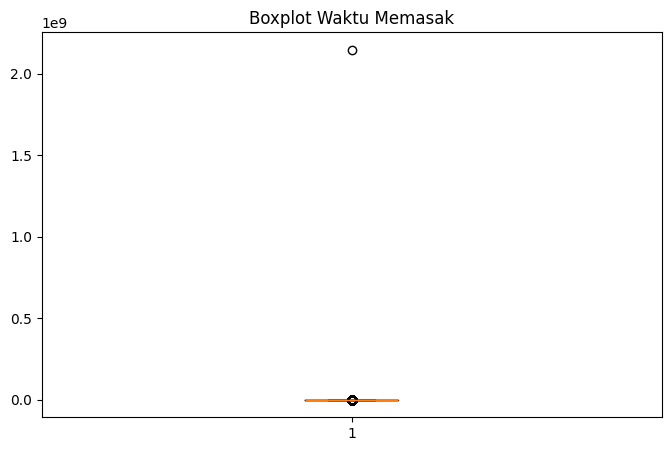

In [21]:
# boxplot
plt.figure(figsize=(8,5))

plt.boxplot(
    df["minutes"]
)

plt.title("Boxplot Waktu Memasak")

plt.show()

In [22]:
df["minutes"].describe(
    percentiles=[0.90,0.95,0.99]
)

count    2.316360e+05
mean     9.398587e+03
std      4.461973e+06
min      0.000000e+00
50%      4.000000e+01
90%      1.350000e+02
95%      2.550000e+02
99%      9.039500e+02
max      2.147484e+09
Name: minutes, dtype: float64

In [23]:
q99 = df["minutes"].quantile(0.99)

print(q99)

903.9499999999825


In [28]:
df["minutes"] = np.where(
    df["minutes"] > q99,
    q99,
    df["minutes"]
)

In [29]:
df["minutes"].describe(
    percentiles=[0.90,0.95,0.99]
)

count    231636.000000
mean         71.550356
std         123.134994
min           0.000000
50%          40.000000
90%         135.000000
95%         255.000000
99%         903.267500
max         903.950000
Name: minutes, dtype: float64

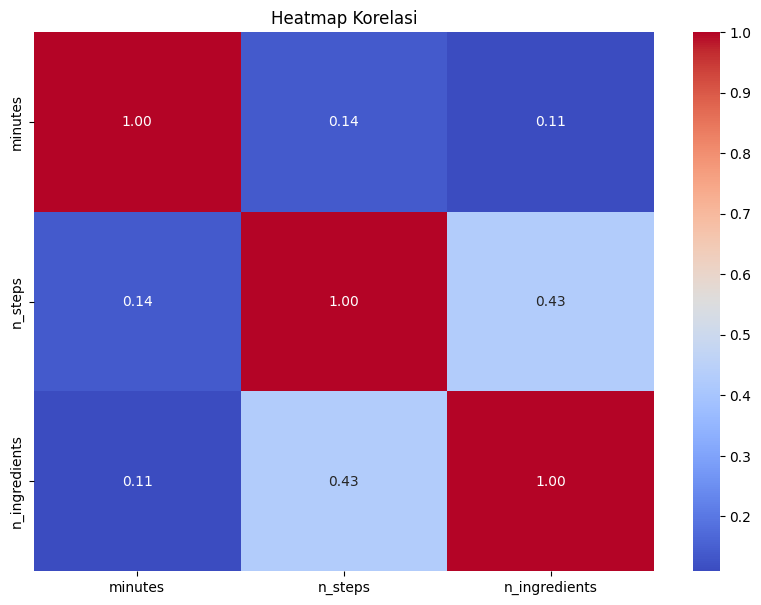

In [30]:
numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Heatmap Korelasi"
)

plt.show()

---
#### feature engineering
Tahap Feature Engineering dilakukan untuk memecah kolom nutrition menjadi 7 indikator zat gizi mandiri (kalori, lemak, gula, sodium, protein, lemak jenuh, dan karbohidrat) serta mengekstrak metrik kuantitas fisik hidangan seperti jumlah tag, jumlah bahan, jumlah langkah, hingga panjang karakter judul dan deskripsi resep, di mana langkah ini sangat urgen untuk mentransformasikan struktur gumpalan teks mentah menjadi sekumpulan matriks prediktor numerik ($X$) yang seragam agar model dapat menghitung bobot kemiripan profil nutrisi dan kompleksitas resep secara akurat

In [31]:
# kalori
df["calories"] = df["nutrition"].apply(
    lambda x: x[0]
)

# nutrisi
df["fat"] = df["nutrition"].apply(
    lambda x: x[1]
)

# gula
df["sugar"] = df["nutrition"].apply(
    lambda x: x[2]
)

# protein
df["protein"] = df["nutrition"].apply(
    lambda x: x[4]
)

#saturated fat
df["saturated_fat"] = df["nutrition"].apply(
    lambda x: x[5]
)

# karbohidrat
df["carbohydrates"] = df["nutrition"].apply(
    lambda x: x[6]
)

# jumlah tag
df["tag_count"] = df["tags"].apply(
    len
)


In [32]:
# cek hasil
print(
    df[
        [
            "name",
            "calories",
            "fat",
            "sugar",
            "protein",
            "saturated_fat",
            "carbohydrates",
            "tag_count",
        ]
    ].head()
)

                                         name  calories   fat  sugar  protein  \
0  arriba   baked winter squash mexican style      51.5   0.0   13.0      2.0   
1            a bit different  breakfast pizza     173.4  18.0    0.0     22.0   
2                   all in the kitchen  chili     269.8  22.0   32.0     39.0   
3                          alouette  potatoes     368.1  17.0   10.0     14.0   
4          amish  tomato ketchup  for canning     352.9   1.0  337.0      3.0   

   saturated_fat  carbohydrates  tag_count  
0            0.0            4.0         20  
1           35.0            1.0         20  
2           27.0            5.0          9  
3            8.0           20.0         30  
4            0.0           28.0         21  


In [33]:
print(type(df["ingredients"].iloc[0]))
print(type(df["tags"].iloc[0]))

<class 'list'>
<class 'list'>


jika tags dan bahan masih berbentuk string, ubah terlebih dahulu menjadi list

In [34]:
# import ast

# recipes["ingredients"] = recipes["ingredients"].apply(
#     ast.literal_eval
# )
# recipes["tags"] = recipes["tags"].apply(
#     ast.literal_eval
# )

# print(type(recipes["ingredients"].iloc[0]))
# print(type(recipes["tags"].iloc[0]))

In [35]:
df["ingredients_text"] = (
    df["ingredients"].apply(lambda x:" ".join(i.replace("_"," ")for i in x)))

df["tags_text"] = (
    df["tags"].apply(lambda x:" ".join(t.replace("_"," ")for t in x)))

In [36]:
df["combined_features"] = (
    df["ingredients_text"]
    + " "
    + df["tags_text"]
)

#### encoding

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df["combined_features"]
)

print(tfidf_matrix.shape)

(231636, 4432)


#### Scaling
scalling dilakukan untuk menyetarakan skala rentang nilai dari seluruh kolom numerik agar algoritma tidak bias bada fitur yang memiliki angka besar saja.

tahap ini menggunakan standardscaler untuk meredam pencilan ekstrem durasi memasak tanpa merusak variasi pola data resep yang lain. kolom prdiktor dipisah, kemudian dihitung nilai rata-rata dan standar devisiasinya, kemudian seluruh angka dikonversi kedalam skala standar baru

In [41]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients",
    "calories",
    "fat",
    "sugar",
    "protein",
    "saturated_fat",
    "carbohydrates",
    "tag_count"
]

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(
    df_scaled[numeric_cols]
)


#### train test split
data yang ada kemudian dipisah menjadi 80 untuk training dan 20 untuk testing. 80:20 dipilih karena menjadi standar umum dalam pemodelan. parameter random_state=42 disematkan untuk mengunci pengacakan data dan hasil pembagian tetap konsisten

In [42]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df_scaled,
    test_size=0.2,
    random_state=42
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (185308, 22)
Test : (46328, 22)


#### save csv

In [43]:
df_scaled.to_csv(
    "food_recommendation_scaaling.csv",
    index=False
)


---
---
---

## Modeling

In [44]:
print("DF")
print(
    df[
        ["minutes","n_steps","n_ingredients"]
    ].head()
)

print("\nDF_SCALED")
print(
    df_scaled[
        ["minutes","n_steps","n_ingredients"]
    ].head()
)

DF
   minutes  n_steps  n_ingredients
0     55.0       11              7
1     30.0        9              6
2    130.0        6             13
3     45.0       11             11
4    190.0        5              8

DF_SCALED
    minutes   n_steps  n_ingredients
0 -0.134409  0.205915      -0.549200
1 -0.337438 -0.127690      -0.816952
2  0.474680 -0.628097       1.057314
3 -0.215620  0.205915       0.521809
4  0.961952 -0.794899      -0.281448


In [46]:
# df_scaled = pd.read_csv(
#     "food_recommendation_scaaling.csv"
# )

# print(df_scaled.shape)

### Content-Based Filtering (Cosine Similarity)

In [47]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

In [48]:
numeric_features = [
    "minutes",
    "n_ingredients",
    "n_steps"
]

numeric_matrix = df_scaled[
    numeric_features
]


In [49]:
print(tfidf_matrix.shape)
print(numeric_matrix.shape)

(231636, 4432)
(231636, 3)


In [50]:
X_cosine = hstack([
    tfidf_matrix,
    numeric_matrix
]).tocsr()

print(type(X_cosine))
print(X_cosine.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(231636, 4435)


In [51]:
def recommend_cosine(keyword, n=5):

    matches = df[
        df["name"].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        return "Resep tidak ditemukan"

    idx = matches.index[0]

    print("RESEP ACUAN:")
    print(
        df.loc[idx, "name"]
    )

    similarity_scores = cosine_similarity(
        X_cosine[idx:idx+1],
        X_cosine
    )[0]

    similar_idx = (
        similarity_scores
        .argsort()[::-1]
    )

    similar_idx = similar_idx[
        1:n+1
    ]

    result = df.iloc[
        similar_idx
    ][
        [
            "name",
            "minutes",
            "n_steps",
            "n_ingredients",
            "ingredients_text",
            "tags_text"
        ]
    ].copy()

    result[
        "similarity_score"
    ] = (
        similarity_scores[
            similar_idx
        ]
    )

    return result

In [52]:
recommend_cosine(
    "ayam"
)

RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
195586,spicy chicken with coconut lime sauce,55.0,9,15,chicken thighs chicken legs peanut oil green o...,60-minutes-or-less time-to-make course main-in...,0.745883
55540,coconut chicken curry with yogurt,60.0,8,16,butter yellow onions garlic cloves ground ging...,curries 60-minutes-or-less time-to-make course...,0.726386
196916,spicy tamil chicken,65.0,13,17,crushed red pepper flakes ground coriander fre...,curries time-to-make course main-ingredient cu...,0.723706
42847,chicken and nut curry,35.0,9,15,onion tomato paste roasted cashew nuts garam m...,curries weeknight 60-minutes-or-less time-to-m...,0.721958
205952,sweet curried chicken yam and apple stew,60.0,10,14,butter onions garlic cloves chicken thighs flo...,60-minutes-or-less time-to-make course main-in...,0.717736


beat this banana bread bukan resep yang dipilih, tetapi merupakan resep pertama yang ada dalam dataset yang mengandung bread. Kemudian cosine akan membaca resep yang ada dalam resep tersebut berdasarkan bahan (ingredients). Selanjutnya, cosine akan menghitung tingkat similaritas berdasarkan bahan.

bread -> beat this banana bread -> TF-IDF Ingredients -> Cari resep dengan bahan paling mirip

### KNN

In [53]:
from sklearn.neighbors import NearestNeighbors

In [54]:
numeric_features = [
    "minutes",
    "n_ingredients",
    "n_steps"
]

numeric_matrix = df_scaled[
    numeric_features
]

In [55]:
X_knn = hstack([
    tfidf_matrix,
    numeric_matrix
]).tocsr()

print(X_knn.shape)

(231636, 4435)


In [56]:
knn = NearestNeighbors(
    n_neighbors=6,
    metric="euclidean"
)

knn.fit(X_knn)

print("Model KNN berhasil dibuat")

Model KNN berhasil dibuat


In [57]:
def recommend_knn(keyword, n=5):

    matches = df[
        df["name"].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        return "Resep tidak ditemukan"

    idx = matches.index[0]

    print("RESEP ACUAN:")
    print(df.loc[idx, "name"])

    distances, indices = knn.kneighbors(
        X_knn[idx:idx+1]
    )

    result = df.iloc[
        indices[0][1:n+1]
    ][
        [
            "name",
            "minutes",
            "n_steps",
            "n_ingredients",
            "ingredients_text",
            "tags_text"
        ]
    ].copy()

    result["distance"] = (
        distances[0][1:n+1]
    )

    return result

In [58]:
recommend_knn("ayam")

RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
208103,taiwanese style three cup chicken,60.0,9,11,vegetable oil chicken thighs sesame oil fresh ...,60-minutes-or-less time-to-make course main-in...,0.995232
229889,yummy coconut curry chicken,80.0,11,12,boneless skinless chicken thighs salt and pepp...,curries time-to-make course main-ingredient cu...,1.010830
210370,thai beef with chiles and basil,40.0,10,12,jasmine rice coconut milk coarse salt fish sau...,curries 60-minutes-or-less time-to-make course...,1.015509
46426,chicken with garlic and lime,40.0,9,12,vegetable oil chicken thighs onion garlic clov...,weeknight 60-minutes-or-less time-to-make cour...,1.017686
46787,chicken country style pollo de hacienda,80.0,10,12,frying chicken flour salt pepper bacon carrots...,time-to-make course main-ingredient cuisine pr...,1.035024


## Recomendation Generation

In [59]:
print("COSINE")
display(
    recommend_cosine("pizza")
)

print("KNN")
display(
    recommend_knn("pizza")
)

COSINE
RESEP ACUAN:
a bit different  breakfast pizza


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
19308,bbq pork pizza,25.0,9,5,sweet onion barbecued pork whole wheat pizza c...,30-minutes-or-less time-to-make course main-in...,0.773252
159133,philadelphia style velveeta pizza,35.0,6,4,prepared pizza crust mozzarella cheese prepare...,60-minutes-or-less time-to-make course main-in...,0.763594
82769,favorite bbq chicken pizza,22.0,9,6,chicken breasts barbecue sauce onion green pep...,30-minutes-or-less time-to-make course main-in...,0.753114
70415,deep dish pizza bundle,35.0,9,6,prepared pizza crust mozzarella cheese pizza s...,60-minutes-or-less time-to-make course prepara...,0.751759
81453,ez cheezy barbecue pizza,20.0,8,4,prepared pizza crust four-cheese mexican blend...,30-minutes-or-less time-to-make course main-in...,0.749387


KNN
RESEP ACUAN:
a bit different  breakfast pizza


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
168055,quick easy healthy mixed seafood pizza,20.0,8,7,pizza crust olive oil pizza sauce seafood garl...,30-minutes-or-less time-to-make course main-in...,0.934034
70415,deep dish pizza bundle,35.0,9,6,prepared pizza crust mozzarella cheese pizza s...,60-minutes-or-less time-to-make course prepara...,0.941351
82769,favorite bbq chicken pizza,22.0,9,6,chicken breasts barbecue sauce onion green pep...,30-minutes-or-less time-to-make course main-in...,0.948526
188135,skillet pizza,25.0,8,7,prepared pizza crust eggs milk pepper bacon ch...,30-minutes-or-less time-to-make course prepara...,0.955263
112991,italian sausage onion pizza,25.0,9,6,sausage bell pepper pizza sauce prepared pizza...,30-minutes-or-less time-to-make course prepara...,0.970785


In [60]:
print("COSINE")
display(
    recommend_cosine("banana bread")
)

print("KNN")
display(
    recommend_knn("banana bread")
)

COSINE
RESEP ACUAN:
beat this  banana bread


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
2120,a winning banana nut bread,70.0,14,10,bananas lemon juice cake flour baking powder s...,weeknight time-to-make course main-ingredient ...,0.726772
17199,banana lemon bread,45.0,16,10,bananas butter all-purpose flour baking powder...,60-minutes-or-less time-to-make course main-in...,0.696801
61624,cream cheese walnut banana bread,70.0,14,11,butter cream cheese sugar eggs flour baking po...,time-to-make course main-ingredient preparatio...,0.694863
17201,banana lemon tea bread,75.0,11,9,butter sugar eggs bananas fresh lemon juice al...,weeknight time-to-make course main-ingredient ...,0.684310
30073,brown butter banana bread,80.0,16,9,butter flour brown sugar baking powder baking ...,time-to-make course main-ingredient cuisine pr...,0.682777


KNN
RESEP ACUAN:
beat this  banana bread


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
17201,banana lemon tea bread,75.0,11,9,butter sugar eggs bananas fresh lemon juice al...,weeknight time-to-make course main-ingredient ...,0.830950
2120,a winning banana nut bread,70.0,14,10,bananas lemon juice cake flour baking powder s...,weeknight time-to-make course main-ingredient ...,0.873416
69945,daughter s banana bread,80.0,11,9,flour salt baking soda baking powder butter su...,time-to-make course main-ingredient preparatio...,0.884889
137619,moist banana walnut bread,90.0,11,10,butter sugar bananas eggs vanilla flour baking...,weeknight time-to-make course main-ingredient ...,0.898588
148639,orange banana nut bread,65.0,13,10,sugar vegetable oil eggs bananas orange juice ...,time-to-make course main-ingredient preparatio...,0.898654


In [61]:
print("COSINE")
display(
    recommend_cosine("ayam")
)

print("KNN")
display(
    recommend_knn("ayam")
)

COSINE
RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
195586,spicy chicken with coconut lime sauce,55.0,9,15,chicken thighs chicken legs peanut oil green o...,60-minutes-or-less time-to-make course main-in...,0.745883
55540,coconut chicken curry with yogurt,60.0,8,16,butter yellow onions garlic cloves ground ging...,curries 60-minutes-or-less time-to-make course...,0.726386
196916,spicy tamil chicken,65.0,13,17,crushed red pepper flakes ground coriander fre...,curries time-to-make course main-ingredient cu...,0.723706
42847,chicken and nut curry,35.0,9,15,onion tomato paste roasted cashew nuts garam m...,curries weeknight 60-minutes-or-less time-to-m...,0.721958
205952,sweet curried chicken yam and apple stew,60.0,10,14,butter onions garlic cloves chicken thighs flo...,60-minutes-or-less time-to-make course main-in...,0.717736


KNN
RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
208103,taiwanese style three cup chicken,60.0,9,11,vegetable oil chicken thighs sesame oil fresh ...,60-minutes-or-less time-to-make course main-in...,0.995232
229889,yummy coconut curry chicken,80.0,11,12,boneless skinless chicken thighs salt and pepp...,curries time-to-make course main-ingredient cu...,1.010830
210370,thai beef with chiles and basil,40.0,10,12,jasmine rice coconut milk coarse salt fish sau...,curries 60-minutes-or-less time-to-make course...,1.015509
46426,chicken with garlic and lime,40.0,9,12,vegetable oil chicken thighs onion garlic clov...,weeknight 60-minutes-or-less time-to-make cour...,1.017686
46787,chicken country style pollo de hacienda,80.0,10,12,frying chicken flour salt pepper bacon carrots...,time-to-make course main-ingredient cuisine pr...,1.035024


## Evaluasi

In [62]:
import numpy as np

- evaluasi cosine: precision at k (p@k), mean average (map), coverage
- evaluasi knn: precision at k (p@k), mean distance efficacy


In [73]:
test_queries = [
 "banana bread",
 "chocolate cake",
 "chicken curry",
 "pizza",
 "cookies",
 "pasta salad"
]

#### Cosine

In [74]:
for q in test_queries:
    recs = recommend_cosine(q)

    print(q)
    print(recs["name"])

RESEP ACUAN:
beat this  banana bread
banana bread
2120           a winning banana nut bread
17199                  banana lemon bread
61624    cream cheese walnut banana bread
17201              banana lemon tea bread
30073           brown butter banana bread
Name: name, dtype: object
RESEP ACUAN:
100 chocolate cake
chocolate cake
85724                          four layer chocolate dessert
138144    mom s chocolate mayonnaise cake with chocolate...
94366                            gorgeous chocolate muffins
120262                       lazy chef s mighty marble cake
191646                               sour cream coffee cake
Name: name, dtype: object
RESEP ACUAN:
creamy  chicken curry
chicken curry
65340     crock pot beef chili with chili creme fraiche
65756                       crock pot creamy beef curry
180022               santa fe chicken salad  applebee s
205757                      sweet beef and fresh chiles
59575                 cowboy steak chili in a crock pot
Name: name, 

In [75]:
def check_relevance(query, row):

    query_words = query.lower().split()

    text = (
        str(row["name"]) + " " +
        str(row["ingredients_text"]) + " " +
        str(row["tags_text"])
    ).lower()

    return any(
        word in text
        for word in query_words
    )

In [76]:
def precision_at_k(query, recommendations):

    relevances = [
        check_relevance(query, row)
        for _, row in recommendations.iterrows()
    ]

    return np.mean(relevances)

In [77]:
def average_precision(query, recommendations):

    relevances = np.array([
        check_relevance(query, row)
        for _, row in recommendations.iterrows()
    ])

    precisions = []

    for i in range(len(relevances)):

        if relevances[i]:

            precisions.append(
                relevances[:i+1].sum() / (i+1)
            )

    if len(precisions) == 0:
        return 0

    return np.mean(precisions)

In [78]:
precision_scores = []
ap_scores = []

for query in test_queries:

    recs = recommend_cosine(
        query,
        n=5
    )

    p = precision_at_k(
        query,
        recs
    )

    ap = average_precision(
        query,
        recs
    )

    precision_scores.append(p)
    ap_scores.append(ap)

    print(
        f"{query} | P@5={p:.3f} | AP={ap:.3f}"
    )

RESEP ACUAN:
beat this  banana bread
banana bread | P@5=1.000 | AP=1.000
RESEP ACUAN:
100 chocolate cake
chocolate cake | P@5=1.000 | AP=1.000
RESEP ACUAN:
creamy  chicken curry
chicken curry | P@5=0.400 | AP=0.583
RESEP ACUAN:
a bit different  breakfast pizza
pizza | P@5=1.000 | AP=1.000
RESEP ACUAN:
1 in canada chocolate chip cookies
cookies | P@5=0.800 | AP=0.887
RESEP ACUAN:
italian sandwich  pasta salad
pasta salad | P@5=1.000 | AP=1.000


In [79]:
map_score = np.mean(
    ap_scores
)

print(
    f"MAP@5 = {map_score:.4f}"
)

MAP@5 = 0.9118


In [80]:
recommended_recipes = set()

for query in test_queries:

    recs = recommend_cosine(
        query,
        n=5
    )

    recommended_recipes.update(
        recs["name"]
    )

RESEP ACUAN:
beat this  banana bread
RESEP ACUAN:
100 chocolate cake
RESEP ACUAN:
creamy  chicken curry
RESEP ACUAN:
a bit different  breakfast pizza
RESEP ACUAN:
1 in canada chocolate chip cookies
RESEP ACUAN:
italian sandwich  pasta salad


In [81]:
coverage = (
    len(recommended_recipes)
    /
    len(df)
)

print(
    f"Coverage = {coverage:.4f}"
)

Coverage = 0.0001


In [82]:
print(
    f"Precision@5 = {np.mean(precision_scores):.4f}"
)

print(
    f"MAP@5 = {map_score:.4f}"
)

print(
    f"Coverage = {coverage:.4f}"
)

Precision@5 = 0.8667
MAP@5 = 0.9118
Coverage = 0.0001


#### KNN

In [83]:
precision_scores = []
ap_scores = []

for query in test_queries:

    recs = recommend_knn(
        query,
        n=5
    )

    p = precision_at_k(
        query,
        recs
    )

    ap = average_precision(
        query,
        recs
    )

    precision_scores.append(p)
    ap_scores.append(ap)

    print(
        f"{query} | P@5={p:.3f} | AP={ap:.3f}"
    )

map_score = np.mean(
    ap_scores
)

print(
    f"MAP@5 = {map_score:.4f}"
)

RESEP ACUAN:
beat this  banana bread
banana bread | P@5=1.000 | AP=1.000
RESEP ACUAN:
100 chocolate cake
chocolate cake | P@5=1.000 | AP=1.000
RESEP ACUAN:
creamy  chicken curry
chicken curry | P@5=0.800 | AP=0.887
RESEP ACUAN:
a bit different  breakfast pizza
pizza | P@5=1.000 | AP=1.000
RESEP ACUAN:
1 in canada chocolate chip cookies
cookies | P@5=0.600 | AP=0.589
RESEP ACUAN:
italian sandwich  pasta salad
pasta salad | P@5=1.000 | AP=1.000
MAP@5 = 0.9127


In [84]:
distance_scores = []

for query in test_queries:

    matches = df[
        df["name"].str.contains(
            query,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        continue

    idx = matches.index[0]

    distances, indices = knn.kneighbors(
        X_knn[idx:idx+1]
    )

    distance_scores.extend(
        distances[0][1:]
    )

mean_distance = np.mean(
    distance_scores
)

print(
    f"Mean Distance = {mean_distance:.4f}"
)

Mean Distance = 1.0189


In [85]:
print(
    f"Precision@5 = {np.mean(precision_scores):.4f}"
)

print(
    f"MAP@5 = {map_score:.4f}"
)

print(
    f"Mean Distance = {mean_distance:.4f}"
)

Precision@5 = 0.9000
MAP@5 = 0.9127
Mean Distance = 1.0189


In [87]:
print(df.columns.tolist())

['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients', 'calories', 'fat', 'sugar', 'protein', 'saturated_fat', 'carbohydrates', 'tag_count', 'ingredients_text', 'tags_text', 'combined_features']


In [88]:
app_df = df[
    [
        "name",
        "minutes",
        "n_steps",
        "n_ingredients",
        "ingredients_text",
        "tags_text",
        "combined_features"
    ]
].copy()

In [89]:
app_df.to_csv(
    "recipes_app.csv",
    index=False
)